In [3]:
## importing libraries 
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 

## loading data 
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

## data cleaning 
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
## install and import seaborn 
import seaborn as sns 

In [5]:
## only get data analyst jobs in the us 
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

## drop Nan value from the coloumn for plotting 
df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])

#   Exercise skill Pay analysis

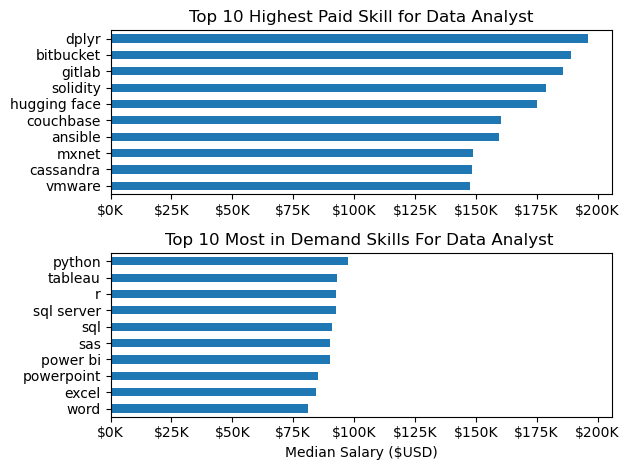

In [6]:
## explode the skill coloum 
df_DA_US=df_DA_US.explode('job_skills')
## make dataframe for hightest salary median
df_DA_US_group=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_Top_pay=df_DA_US_group.sort_values(by='median',ascending=False).head(10)
## data frames for skill with highest count 
df_DA_Skills=df_DA_US_group.sort_values(
    by='count',ascending=False).head(10).sort_values(
        by='median',ascending=False)

## make two graph subplots 
fig ,ax =plt.subplots(2,1)

## plot the TOP pay  on bar graph 
df_DA_Top_pay[::-1].plot(kind='barh',y='median',ax=ax[0],legend=False)
## set title and labels 
ax[0].set_title('Top 10 Highest Paid Skill for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _ :f'${int(x/1000)}K'))

## plot the TOP skill salary on bar garph 
df_DA_Skills[::-1].plot(kind='barh',y='median',ax=ax[1],legend=False)
## set title and labels 
ax[1].set_title('Top 10 Most in Demand Skills For Data Analyst ')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _ :f'${int(x/1000)}K'))


## matching the x axis of both the chart to same number so fair to compare 
ax[1].set_xlim(ax[0].get_xlim())

## fig tight layout 
fig.tight_layout()
## showing the chart 
plt.show()

## makeing it with seaborn 

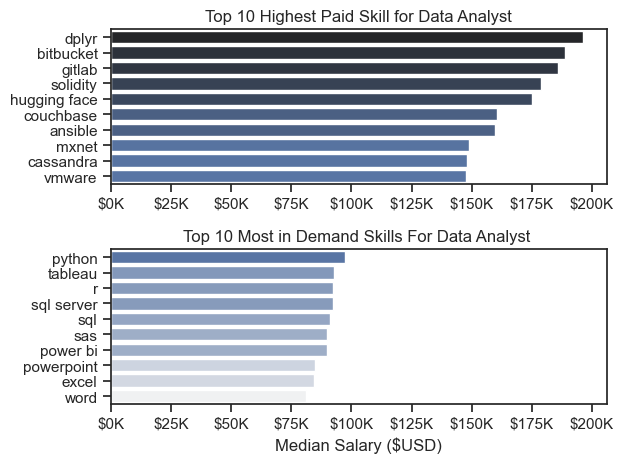

In [13]:
## make two graph subplots 
fig ,ax =plt.subplots(2,1)

##set theme of graph 
sns.set_theme(style='ticks')

## Top 10 Highest paid skill for data analyst
sns.barplot(data=df_DA_Top_pay,x='median',y=df_DA_Top_pay.index,ax=ax[0],hue='median',palette= 'dark:b_r')
ax[0].legend().remove()
## set title and labels 
ax[0].set_title('Top 10 Highest Paid Skill for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _ :f'${int(x/1000)}K'))

## plot the TOP skill salary on bar garph 
sns.barplot(data=df_DA_Skills,x='median',y=df_DA_Skills.index,ax=ax[1],hue='median',palette='light:b')
ax[1].legend().remove()

## set title and labels 
ax[1].set_title('Top 10 Most in Demand Skills For Data Analyst ')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _ :f'${int(x/1000)}K'))

## matching the x axis of both the chart to same number so fair to compare 
ax[1].set_xlim(ax[0].get_xlim())

## fig tight layout 
fig.tight_layout()

## showing the chart 
plt.show()

# histogram with seaborn 
 ## this is draw with matplotlib

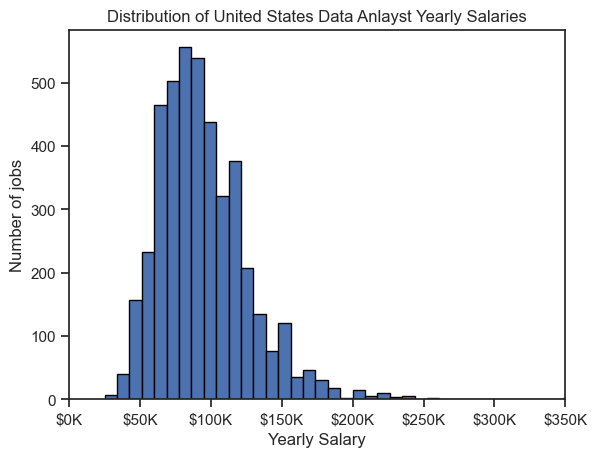

In [15]:
## only get data analyst jobs in the us 
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

## plot the histogram 
df_DA_US['salary_year_avg'].plot(kind='hist', bins=40,edgecolor='black')
plt.xlim(0,350000)

## formatting the x axis 
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _: f'${int(x/1000)}K'))

## formatting the title and label 
plt.title('Distribution of United States Data Anlayst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of jobs')

## show the histogram 
plt.show()


## histogram with seaborn 


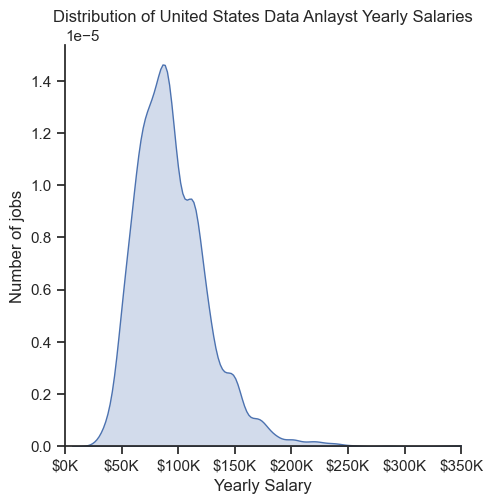

In [19]:
## set theme 
sns.set_theme(style='ticks')

## plot the histogram 
sns.displot(df_DA_US['salary_year_avg'],kind='kde',fill=True)
plt.xlim(0,350000)

## formatting the x axis 
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _: f'${int(x/1000)}K'))

## formatting the title and label 
plt.title('Distribution of United States Data Anlayst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of jobs')

## show the histogram 
plt.show()